## Frame Extracting

In [5]:
import cv2
import os

# INPUT VIDEO PATH
input_video_path = r"D:\Downloads\IP_Project\Road_Damaged_Video.mp4"

# OUTPUT FOLDER
extract_frame_dir = r"D:\Downloads\IP_Project\Extracted_frames"

# Create folder
if not os.path.exists(extract_frame_dir):
    os.makedirs(extract_frame_dir)

# READ VIDEO
cap = cv2.VideoCapture(input_video_path)

frame_count = 0

# FRAME EXTRACTION LOOP
while True:

    ret, frame = cap.read()

    # Stop when video ends
    if not ret:
        break

    # Create frame file name
    frame_name = os.path.join(
        extract_frame_dir,
        f"frame_{frame_count:05d}.jpg"
    )

    # Save frame
    cv2.imwrite(frame_name, frame)

    frame_count += 1

# RELEASE VIDEO
cap.release()

print(f"Extracted {frame_count} frames successfully.")

Extracted 453 frames successfully.


## Enhance Pipeline


Total extracted frames found: 453
Enhancement completed.
Enhanced frames saved in: D:\Downloads\IP_Project\Enhanced_frames

--- Result for: frame_00000.jpg ---
Mean:      64.00 -> 80.67
Std Dev:   15.48 -> 21.75
Sharpness: 128.45 -> 256.73


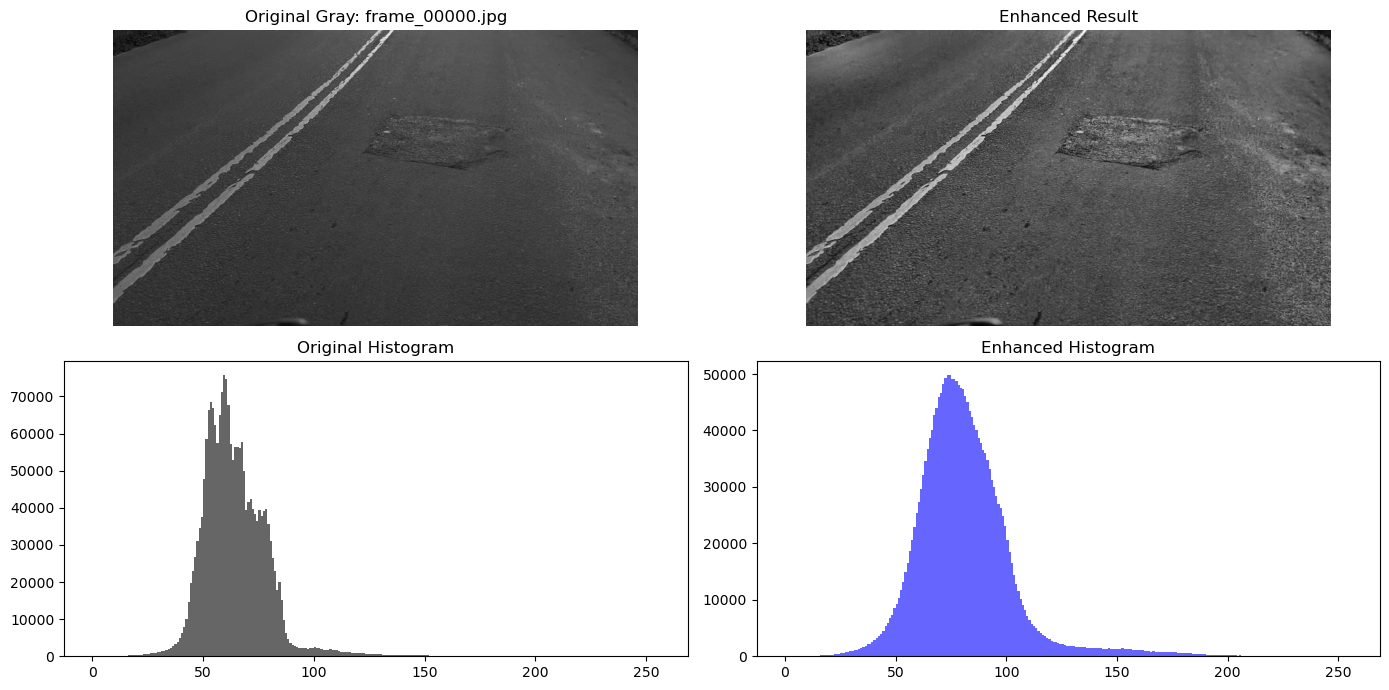


--- Result for: frame_00050.jpg ---
Mean:      63.28 -> 79.87
Std Dev:   17.50 -> 22.92
Sharpness: 88.39 -> 179.31


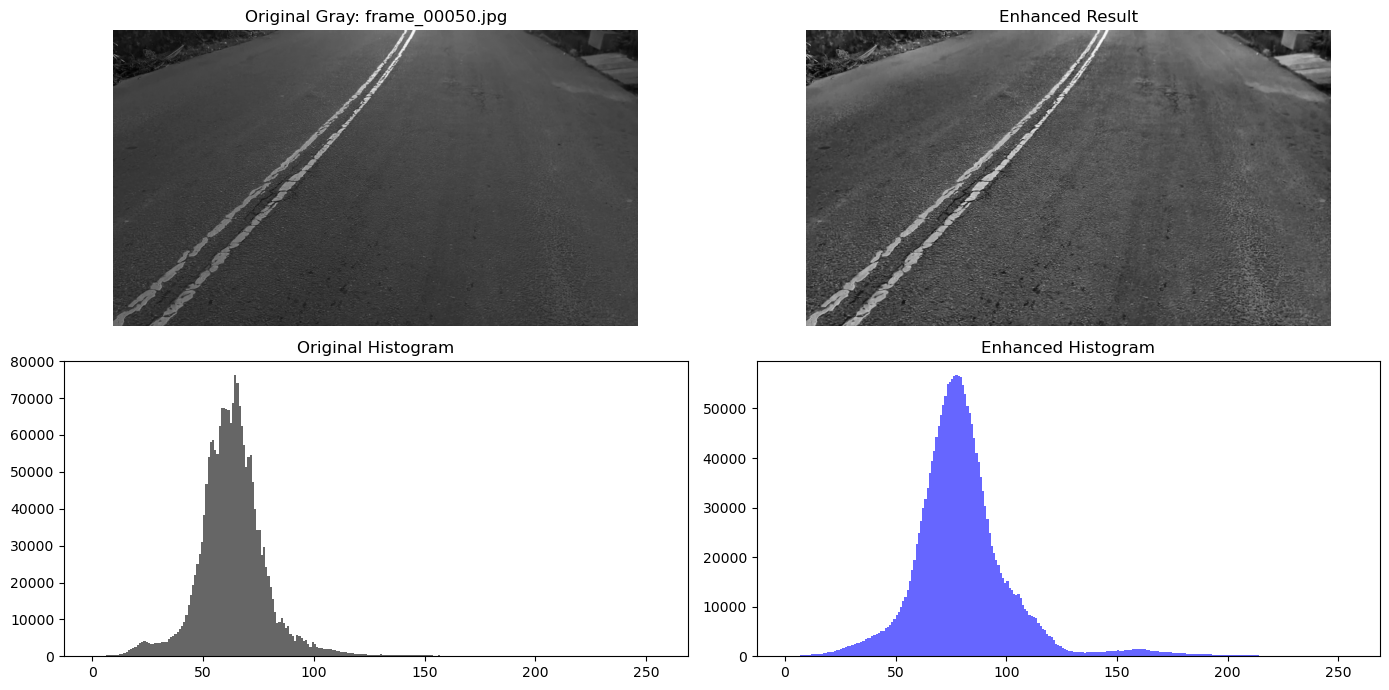


--- Result for: frame_00100.jpg ---
Mean:      62.39 -> 79.66
Std Dev:   18.62 -> 24.17
Sharpness: 124.98 -> 282.52


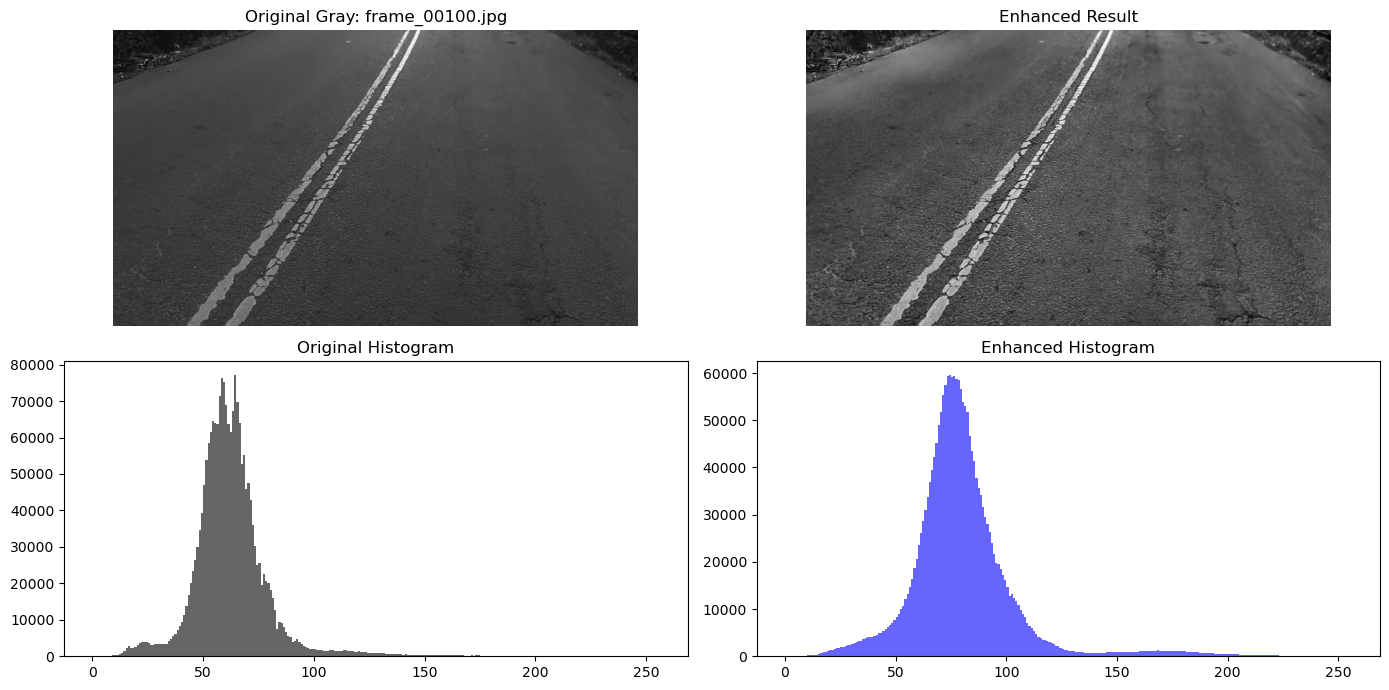

In [6]:
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# Folders select 
# Folders select 

input_dir = r"D:\Downloads\IP_Project\Extracted_frames"

enhanced_dir =r"D:\Downloads\IP_Project\Enhanced_frames"

os.makedirs(enhanced_dir, exist_ok=True)

# METRICS FUNCTION
def compute_metrics(original, enhanced):
    mean_orig = np.mean(original)
    mean_enh = np.mean(enhanced)

    std_orig = np.std(original)
    std_enh = np.std(enhanced)

    sharp_orig = cv2.Laplacian(original, cv2.CV_64F).var()
    sharp_enh = cv2.Laplacian(enhanced, cv2.CV_64F).var()

    return mean_orig, mean_enh, std_orig, std_enh, sharp_orig, sharp_enh

# ENHANCEMENT PIPELINE
def master_pipeline_enhance(gray):

    enhanced = gray.copy()

    mean_val = np.mean(gray)
    std_val = np.std(gray)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Step 1: Conditional CLAHE
    if mean_val < 90 or std_val < 40:
        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )
        enhanced = clahe.apply(enhanced)

    # Step 2: Bilateral Filter
    enhanced = cv2.bilateralFilter(
        enhanced,
        d=5,
        sigmaColor=25,
        sigmaSpace=25
    )

    # Step 3: Conditional Sharpening
    if sharpness < 50:
        blur = cv2.GaussianBlur(enhanced, (3, 3), 0)
        enhanced = cv2.addWeighted(enhanced, 1.5, blur, -0.5, 0)

    return enhanced

# READ ALL FRAMES
frame_paths = sorted(glob.glob(os.path.join(input_dir, "*.jpg")))

print("Total extracted frames found:", len(frame_paths))

# PROCESS AND SAVE ALL ENHANCED FRAMES
for path in frame_paths:

    img = cv2.imread(path)

    if img is None:
        print("Skipped:", path)
        continue

    frame_name = os.path.basename(path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    enhanced = master_pipeline_enhance(gray)

    save_path = os.path.join(enhanced_dir, frame_name)
    cv2.imwrite(save_path, enhanced)

print("Enhancement completed.")
print("Enhanced frames saved in:", enhanced_dir)

# DISPLAY ONLY 3 SAMPLE RESULTS WITH HISTOGRAMS
test_frames = ["frame_00000.jpg", "frame_00050.jpg", "frame_00100.jpg"]

for frame_name in test_frames:

    original_path = os.path.join(input_dir, frame_name)
    enhanced_path = os.path.join(enhanced_dir, frame_name)

    img = cv2.imread(original_path)
    enhanced = cv2.imread(enhanced_path, cv2.IMREAD_GRAYSCALE)

    if img is None or enhanced is None:
        print(f"{frame_name} not found.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    m_o, m_e, s_o, s_e, sh_o, sh_e = compute_metrics(gray, enhanced)

    print(f"\n--- Result for: {frame_name} ---")
    print(f"Mean:      {m_o:.2f} -> {m_e:.2f}")
    print(f"Std Dev:   {s_o:.2f} -> {s_e:.2f}")
    print(f"Sharpness: {sh_o:.2f} -> {sh_e:.2f}")

    plt.figure(figsize=(14, 7))

    plt.subplot(2, 2, 1)
    plt.imshow(gray, cmap="gray")
    plt.title(f"Original Gray: {frame_name}")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(enhanced, cmap="gray")
    plt.title("Enhanced Result")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.hist(gray.ravel(), bins=256, range=(0, 256), color="black", alpha=0.6)
    plt.title("Original Histogram")

    plt.subplot(2, 2, 4)
    plt.hist(enhanced.ravel(), bins=256, range=(0, 256), color="blue", alpha=0.6)
    plt.title("Enhanced Histogram")

    plt.tight_layout()
    plt.show()